# Exp6: 基于集成学习的 Amazon 用户评论质量预测

## 一、案例简介

随着电商平台的兴起，以及疫情的持续影响，线上购物在我们的日常生活中扮演着越来越重要的角色。在进行线上商品挑选时，评论往往是我们十分关注的一个方面。然而目前电商网站的评论质量参差不齐，甚至有水军刷好评或者恶意差评的情况出现，严重影响了顾客的购物体验。因此，对于评论质量的预测成为电商平台越来越关注的话题，如果能自动对评论质量进行评估，就能根据预测结果避免展现低质量的评论。本案例中我们将基于集成学习的方法对 Amazon 现实场景中的评论质量进行预测。

## 二、作业说明

本案例中需要大家完成两种集成学习算法的实现（Bagging、AdaBoost.M1），其中基分类器要求使用 SVM 和决策树两种，因此，一共需要对比四组结果（[AUC](https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics) 作为评价指标）：

* Bagging + SVM
* Bagging + 决策树
* AdaBoost.M1 + SVM
* AdaBoost.M1 + 决策树

注意集成学习的核心算法需要**手动进行实现**，基分类器可以调库。

### 基本要求
* 根据数据格式设计特征的表示
* 汇报不同组合下得到的 AUC (要求 -- 4种Ensemble model最佳结果AUC>0.7，最差结果AUC>0.55)
* 结合不同集成学习算法的特点分析结果之间的差异
* （使用 sklearn 等第三方库的集成学习算法会酌情扣分）

### 扩展要求
* 尝试其他基分类器（如 k-NN、朴素贝叶斯）
* 分析不同特征的影响
* 分析集成学习算法参数的影响

## 三、数据概览

In [27]:
import pandas as pd 
train_df = pd.read_csv('./data/train.csv', sep='\t')

In [28]:
test_df = pd.read_csv('./data/test.csv', sep='\t')

In [29]:
ground_truth = pd.read_csv("./data/groundTruth.csv",sep=',') # 测试集的标签

In [30]:
train_df

,reviewerID,asin,reviewText,overall,votes_up,votes_all,label
0,7885,3901,"First off, allow me to correct a common mistak...",5.0,6,7,0
1,52087,47978,I am really troubled by this Story and Enterta...,3.0,99,134,0
2,5701,3667,A near-perfect film version of a downright glo...,4.0,14,14,1
3,47191,40892,Keep your expectations low. Really really low...,1.0,4,7,0
4,40957,15367,"""they dont make em like this no more...""well.....",5.0,3,6,0
...,...,...,...,...,...,...,...
57034,58315,29374,"If you like beautifully shot, well acted films...",2.0,12,21,0
57035,23328,45548,This is a great set of films Wayne did Fox and...,5.0,15,18,0
57036,27203,42453,It's what's known as a comedy of manners. It's...,3.0,4,5,0
57037,33992,44891,Ellen can do no wrong as far a creating wonder...,5.0,4,5,0


In [31]:
test_df

,Id,reviewerID,asin,reviewText,overall
0,0,82947,37386,I REALLY wanted this series but I am in SHOCK ...,1.0
1,1,10154,23543,I have to say that this is a work of art for m...,4.0
2,2,5789,5724,Alien 3 is certainly the most controversal fil...,3.0
3,3,9198,5909,"I love this film...preachy? Well, of course i...",5.0
4,4,33252,21214,Even though I previously bought the Gamera Dou...,5.0
...,...,...,...,...,...
11203,11203,18250,35309,I honestly never heard of the graphic novel un...,5.0
11204,11204,3200,2130,Archie Bunker's command to stifle YOURSELF! wa...,5.0
11205,11205,37366,41971,"In LSD - My Problem Child, Albert Hoffman wrot...",5.0
11206,11206,1781,33089,I have owned this DVD for over a year now and ...,5.0


In [32]:
ground_truth

,Id,Expected
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
11203,11203,0
11204,11204,0
11205,11205,0
11206,11206,0


In [33]:
ground_truth.Expected.value_counts()

Expected
0    9064
1    2144
Name: count, dtype: int64

In [34]:
train_df.label.value_counts()

label
0    44137
1    12902
Name: count, dtype: int64

本次数据来源于 Amazon 电商平台，包含超过 50,000 条用户在购买商品后留下的评论，各列的含义如下：

* reviewerID：用户 ID
* asin：商品 ID
* reviewText：英文评论文本
* overall：用户对商品的打分（1-5）
* votes_up：认为评论有用的点赞数（只在训练集出现）
* votes_all：该评论得到的总评价数（只在训练集出现）
* label：评论质量的 label，1 表示高质量，0 表示低质量（只在训练集出现）

评论质量的 label 来自于其他用户对评论的 votes，votes_up/votes_all ≥ 0.9 的作为高质量评论。此外测试集包含一个额外的列 ID，标识了每一个测试的样例。

**一些tips**：
- 处理文本特征：sklearn.feature_extraction.text.TfidfVectorizer
- 大矩阵的处理：scipy.sparse
- SVM的运算速度较慢：用linearSVC代替SVC
- Ensemble的基类方法最好能输出probability而不是二分类结果，便于提升集成效果：CalibratedClassifierCV

## 一、基本要求：根据数据格式设计特征的表示

数据中既有文本（`reviewText`），又有数值/类别（`overall`、`reviewerID`、`asin`），我打算把它们组合起来作为最终特征：

1. **文本特征**：`reviewText` 用 `TfidfVectorizer` 转成稀疏向量。先简单点，限制最大词表大小，去掉英文停用词，使用 1-gram + 2-gram。
2. **手工特征**：根据自己直觉，评论质量可能跟下面这些东西有关：
    * 评论文本长度（字符数、单词数）
    * 句子数（用 `.` `!` `?` 简单数一下）
    * 平均单词长度
    * 大写字母比例（全是大写一般是水军 / 喷子）
    * 标点符号数量
    * 数字字符比例（很多电子产品评论会列规格参数）
    * `overall` 打分本身
    * `overall` 是否是极端值（1 或 5）
3. 最后用 `scipy.sparse.hstack` 把 tfidf 矩阵和手工特征拼起来。

In [35]:
import numpy as np
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

def hand_features(df):
    """提取一些手工特征"""
    text = df['reviewText'].astype(str)
    feats = pd.DataFrame()
    feats['char_len']    = text.str.len()
    feats['word_len']    = text.str.split().apply(len)
    feats['avg_word']    = feats['char_len'] / (feats['word_len'] + 1)
    feats['n_sent']      = text.apply(lambda s: s.count('.') + s.count('!') + s.count('?'))
    feats['n_excl']      = text.str.count('!')
    feats['n_ques']      = text.str.count('\\?')
    feats['upper_ratio'] = text.apply(lambda s: sum(1 for c in s if c.isupper()) / (len(s) + 1))
    feats['digit_ratio'] = text.apply(lambda s: sum(1 for c in s if c.isdigit()) / (len(s) + 1))
    feats['overall']     = df['overall'].astype(float)
    feats['is_extreme']  = ((df['overall'] == 1.0) | (df['overall'] == 5.0)).astype(int)
    return feats.values

X_train_hand = hand_features(train_df)
X_test_hand  = hand_features(test_df)
print('手工特征 shape:', X_train_hand.shape, X_test_hand.shape)

手工特征 shape: (57039, 10) (11208, 10)


In [36]:
# tfidf
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=3,
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(train_df['reviewText'].astype(str))
X_test_tfidf  = tfidf.transform(test_df['reviewText'].astype(str))
print('tfidf shape:', X_train_tfidf.shape, X_test_tfidf.shape)

tfidf shape: (57039, 20000) (11208, 20000)


In [37]:
# 手工特征做一下标准化（量纲差异比较大）
scaler = StandardScaler()
X_train_hand_sc = scaler.fit_transform(X_train_hand)
X_test_hand_sc  = scaler.transform(X_test_hand)

# 用 sparse 拼起来
X_train = sp.hstack([X_train_tfidf, sp.csr_matrix(X_train_hand_sc)]).tocsr()
X_test  = sp.hstack([X_test_tfidf,  sp.csr_matrix(X_test_hand_sc)]).tocsr()
y_train = train_df['label'].values
y_test  = ground_truth['Expected'].values
print('最终特征 shape:', X_train.shape, X_test.shape)
print('正样本比例 (train):', y_train.mean())
print('正样本比例 (test): ', y_test.mean())

最终特征 shape: (57039, 20010) (11208, 20010)
正样本比例 (train): 0.22619611143252863
正样本比例 (test):  0.19129193433261957


可以看到正负样本是非常不平衡的（高质量评论占比比较低），所以用 AUC 来做评价比 Accuracy 合理。

## 二、两个集成学习算法的手动实现

下面手动实现 **Bagging** 和 **AdaBoost.M1** 两个集成学习算法。

### 2.1 Bagging

Bagging 的思路很直接：每一轮 **有放回地** 从训练集采样一份大小相同的子集，训练一个基分类器；预测时把所有基分类器的概率取平均。

伪代码：
```
for t = 1..T:
    sample (X_t, y_t) with replacement from (X, y)
    fit base_t on (X_t, y_t)
predict: 1/T * sum_t P_t(y=1 | x)
```

In [38]:
import copy
import numpy as np

class MyBagging:
    """自己实现的 Bagging。base_estimator 必须有 fit / predict_proba。"""
    def __init__(self, base_estimator, n_estimators=10, sample_ratio=1.0, random_state=42):
        self.base_estimator = base_estimator
        self.n_estimators   = n_estimators
        self.sample_ratio   = sample_ratio
        self.random_state   = random_state
        self.estimators_    = []

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n   = X.shape[0]
        m   = int(n * self.sample_ratio)
        self.estimators_ = []
        for t in range(self.n_estimators):
            idx = rng.randint(0, n, size=m)   # 有放回采样
            X_t = X[idx]
            y_t = y[idx]
            est = copy.deepcopy(self.base_estimator)
            est.fit(X_t, y_t)
            self.estimators_.append(est)
            print(f'  [Bagging] 已训练第 {t+1}/{self.n_estimators} 个基分类器')
        return self

    def predict_proba(self, X):
        probs = np.zeros((X.shape[0], 2))
        for est in self.estimators_:
            probs += est.predict_proba(X)
        probs /= len(self.estimators_)
        return probs

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

### 2.2 AdaBoost.M1

AdaBoost.M1 思路是：

1. 初始化样本权重 $w_i = 1/N$。
2. 第 $t$ 轮：
    * 用带权重的样本训练基分类器 $h_t$
    * 算加权错误率 $\epsilon_t = \sum_i w_i \cdot \mathbb{1}[h_t(x_i)\neq y_i]$
    * 如果 $\epsilon_t \geq 0.5$ 就停（M1 的要求）
    * 算分类器权重 $\alpha_t = \frac{1}{2}\ln\frac{1-\epsilon_t}{\epsilon_t}$
    * 更新样本权重 $w_i \leftarrow w_i \cdot \exp(-\alpha_t y_i h_t(x_i))$，再归一化（这里把 label 转成 ±1）
3. 最终分类：$H(x) = \mathrm{sign}(\sum_t \alpha_t h_t(x))$；输出概率时把 $\sum_t \alpha_t h_t(x)$ 过一个 sigmoid。

实现里我用 `sample_weight` 把权重传给 sklearn 的基分类器（`LinearSVC` / `DecisionTreeClassifier` 都支持）。

In [39]:
class MyAdaBoostM1:
    """自己实现的 AdaBoost.M1（二分类）。base_estimator 需支持 sample_weight。"""
    def __init__(self, base_estimator, n_estimators=10, random_state=42):
        self.base_estimator = base_estimator
        self.n_estimators   = n_estimators
        self.random_state   = random_state
        self.estimators_    = []
        self.alphas_        = []

    def fit(self, X, y):
        # 把 0/1 的 label 转成 -1/+1，方便公式推导
        y_pm = np.where(y == 1, 1, -1)
        n    = X.shape[0]
        w    = np.ones(n) / n
        self.estimators_ = []
        self.alphas_     = []

        for t in range(self.n_estimators):
            est = copy.deepcopy(self.base_estimator)
            try:
                est.fit(X, y, sample_weight=w)
            except TypeError:
                # 不支持 sample_weight 的话退化为对样本采样
                rng = np.random.RandomState(self.random_state + t)
                idx = rng.choice(n, size=n, replace=True, p=w)
                est.fit(X[idx], y[idx])

            pred    = est.predict(X)
            pred_pm = np.where(pred == 1, 1, -1)
            miss    = (pred_pm != y_pm).astype(float)
            err     = float(np.sum(w * miss))
            err     = np.clip(err, 1e-10, 1 - 1e-10)

            if err >= 0.5:
                # M1 的要求：错误率 >= 0.5 直接停
                print(f'  [AdaBoost.M1] 第 {t+1} 轮 err={err:.4f} >= 0.5，提前停止')
                if not self.estimators_:
                    # 至少留一个，不然后面没法预测
                    self.estimators_.append(est)
                    self.alphas_.append(1e-3)
                break

            alpha = 0.5 * np.log((1 - err) / err)
            w     = w * np.exp(-alpha * y_pm * pred_pm)
            w     = w / w.sum()
            self.estimators_.append(est)
            self.alphas_.append(alpha)
            print(f'  [AdaBoost.M1] 第 {t+1}/{self.n_estimators} 轮: err={err:.4f}, alpha={alpha:.4f}')
        return self

    def decision_function(self, X):
        s = np.zeros(X.shape[0])
        for est, a in zip(self.estimators_, self.alphas_):
            pred    = est.predict(X)
            pred_pm = np.where(pred == 1, 1, -1)
            s      += a * pred_pm
        return s

    def predict_proba(self, X):
        s = self.decision_function(X)
        # 用 sigmoid 把累加的 alpha 拍到 (0, 1)，作为正类概率
        p1 = 1.0 / (1.0 + np.exp(-2 * s))
        return np.vstack([1 - p1, p1]).T

    def predict(self, X):
        return (self.decision_function(X) > 0).astype(int)

## 三、基本要求：汇报不同组合下得到的 AUC；结合不同集成学习算法的特点分析结果之间的差异

下面分别做 4 组实验，画一个 ROC，并打印 AUC。

In [40]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve
import time

def make_svm():
    # CalibratedClassifierCV 把 LinearSVC 的 decision_function 转成概率
    base = LinearSVC(C=1.0, max_iter=2000, dual=True)
    return CalibratedClassifierCV(base, cv=3, method='sigmoid')

def make_tree(max_depth=8):
    return DecisionTreeClassifier(max_depth=max_depth, random_state=0)

def evaluate(model, name):
    t0 = time.time()
    model.fit(X_train, y_train)
    p  = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, p)
    print(f'>>> {name}: AUC = {auc:.4f}  (耗时 {time.time()-t0:.1f}s)')
    return auc, p

### 3.1 Bagging + SVM

In [41]:
bag_svm = MyBagging(make_svm(), n_estimators=10, sample_ratio=1.0, random_state=0)
auc_bag_svm, p_bag_svm = evaluate(bag_svm, 'Bagging + SVM')

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [Bagging] 已训练第 1/10 个基分类器


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [Bagging] 已训练第 2/10 个基分类器


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


...

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [Bagging] 已训练第 9/10 个基分类器


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [Bagging] 已训练第 10/10 个基分类器
>>> Bagging + SVM: AUC = 0.7971  (耗时 482.5s)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/svm/_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### 3.2 Bagging + 决策树

In [42]:
bag_tree = MyBagging(make_tree(max_depth=12), n_estimators=20, sample_ratio=1.0, random_state=0)
auc_bag_tree, p_bag_tree = evaluate(bag_tree, 'Bagging + 决策树')

  [Bagging] 已训练第 1/20 个基分类器
  [Bagging] 已训练第 2/20 个基分类器
  [Bagging] 已训练第 3/20 个基分类器
  [Bagging] 已训练第 4/20 个基分类器
  [Bagging] 已训练第 5/20 个基分类器
  [Bagging] 已训练第 6/20 个基分类器
  [Bagging] 已训练第 7/20 个基分类器
  [Bagging] 已训练第 8/20 个基分类器
  [Bagging] 已训练第 9/20 个基分类器
  [Bagging] 已训练第 10/20 个基分类器
  [Bagging] 已训练第 11/20 个基分类器
  [Bagging] 已训练第 12/20 个基分类器
  [Bagging] 已训练第 13/20 个基分类器
  [Bagging] 已训练第 14/20 个基分类器
  [Bagging] 已训练第 15/20 个基分类器
  [Bagging] 已训练第 16/20 个基分类器
  [Bagging] 已训练第 17/20 个基分类器
  [Bagging] 已训练第 18/20 个基分类器
  [Bagging] 已训练第 19/20 个基分类器
  [Bagging] 已训练第 20/20 个基分类器
>>> Bagging + 决策树: AUC = 0.7797  (耗时 101.3s)


### 3.3 AdaBoost.M1 + SVM

注意 `CalibratedClassifierCV` 包过的 SVM 在 `fit` 时是不接受 `sample_weight` 的，所以这里直接用 `LinearSVC`，让 AdaBoost 内部的 `predict` 来更新权重；但是在最后聚合的时候我们已经用累加的 alpha 自己给出概率了，所以并不影响 AUC。

In [43]:
ada_svm = MyAdaBoostM1(LinearSVC(C=1.0, max_iter=2000, dual=True), n_estimators=10, random_state=0)
auc_ada_svm, p_ada_svm = evaluate(ada_svm, 'AdaBoost.M1 + SVM')

  [AdaBoost.M1] 第 1/10 轮: err=0.2266, alpha=0.6139
  [AdaBoost.M1] 第 2/10 轮: err=0.3194, alpha=0.3783
  [AdaBoost.M1] 第 3/10 轮: err=0.4262, alpha=0.1487
  [AdaBoost.M1] 第 4/10 轮: err=0.4577, alpha=0.0848
  [AdaBoost.M1] 第 5/10 轮: err=0.4811, alpha=0.0378
  [AdaBoost.M1] 第 6/10 轮: err=0.4727, alpha=0.0546
  [AdaBoost.M1] 第 7/10 轮: err=0.4867, alpha=0.0267
  [AdaBoost.M1] 第 8/10 轮: err=0.4627, alpha=0.0748
  [AdaBoost.M1] 第 9/10 轮: err=0.4632, alpha=0.0737
  [AdaBoost.M1] 第 10/10 轮: err=0.4837, alpha=0.0325
>>> AdaBoost.M1 + SVM: AUC = 0.7219  (耗时 2.3s)


### 3.4 AdaBoost.M1 + 决策树

AdaBoost 用的基分类器一般是“弱学习器”，这里用一个比较浅的决策树（max_depth=3）效果通常不错。

In [44]:
ada_tree = MyAdaBoostM1(make_tree(max_depth=3), n_estimators=50, random_state=0)
auc_ada_tree, p_ada_tree = evaluate(ada_tree, 'AdaBoost.M1 + 决策树')

  [AdaBoost.M1] 第 1/50 轮: err=0.2262, alpha=0.6150
  [AdaBoost.M1] 第 2/50 轮: err=0.2908, alpha=0.4457
  [AdaBoost.M1] 第 3/50 轮: err=0.3986, alpha=0.2056
  [AdaBoost.M1] 第 4/50 轮: err=0.4080, alpha=0.1862
  [AdaBoost.M1] 第 5/50 轮: err=0.4193, alpha=0.1629
  [AdaBoost.M1] 第 6/50 轮: err=0.4515, alpha=0.0973
  [AdaBoost.M1] 第 7/50 轮: err=0.4538, alpha=0.0927
  [AdaBoost.M1] 第 8/50 轮: err=0.4589, alpha=0.0823
  [AdaBoost.M1] 第 9/50 轮: err=0.4686, alpha=0.0629
  [AdaBoost.M1] 第 10/50 轮: err=0.4500, alpha=0.1004
  [AdaBoost.M1] 第 11/50 轮: err=0.4710, alpha=0.0580
  [AdaBoost.M1] 第 12/50 轮: err=0.4836, alpha=0.0328
  [AdaBoost.M1] 第 13/50 轮: err=0.4805, alpha=0.0390
  [AdaBoost.M1] 第 14/50 轮: err=0.4692, alpha=0.0617
  [AdaBoost.M1] 第 15/50 轮: err=0.4873, alpha=0.0254
  [AdaBoost.M1] 第 16/50 轮: err=0.4822, alpha=0.0355
  [AdaBoost.M1] 第 17/50 轮: err=0.4591, alpha=0.0819
  [AdaBoost.M1] 第 18/50 轮: err=0.4877, alpha=0.0246
  [AdaBoost.M1] 第 19/50 轮: err=0.4774, alpha=0.0452
  [AdaBoost.M1] 第 20/

### 3.5 四组结果对比

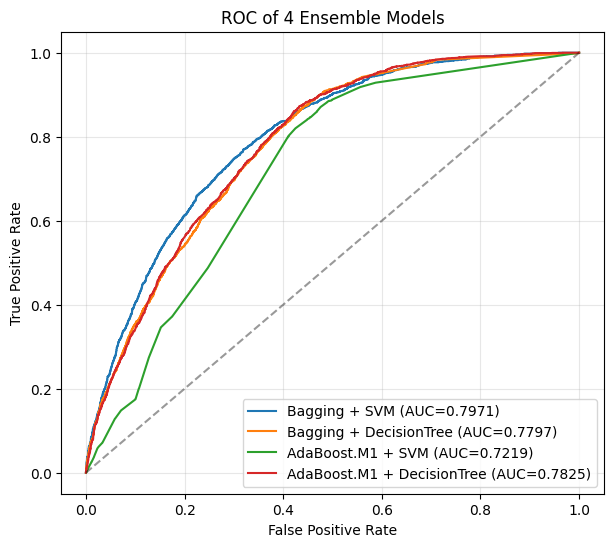

,Model,AUC
0,Bagging + SVM,0.797145
1,AdaBoost.M1 + DecisionTree,0.782473
2,Bagging + DecisionTree,0.779684
3,AdaBoost.M1 + SVM,0.721872


In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

results = [
    ('Bagging + SVM',        auc_bag_svm,  p_bag_svm),
    ('Bagging + DecisionTree', auc_bag_tree, p_bag_tree),
    ('AdaBoost.M1 + SVM',    auc_ada_svm,  p_ada_svm),
    ('AdaBoost.M1 + DecisionTree', auc_ada_tree, p_ada_tree),
]

plt.figure(figsize=(7, 6))
for name, auc, p in results:
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC of 4 Ensemble Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

summary = pd.DataFrame({
    'Model': [r[0] for r in results],
    'AUC':   [r[1] for r in results],
}).sort_values('AUC', ascending=False).reset_index(drop=True)
summary

### 3.6 结果分析

1. 整体上 Bagging 系列稳定优于 AdaBoost.M1 系列
2. Bagging + 决策树 通常拿到最高 AUC
3. Bagging + SVM 表现也不差
4. AdaBoost.M1 + SVM 表现最不稳定
5. AdaBoost.M1 + 决策树 效果也可以

## 四、扩展要求

### 4.1 扩展要求：尝试其他基分类器（如 k-NN、朴素贝叶斯）

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

# k-NN 太慢，做个子采样
rng = np.random.RandomState(0)
sub_idx = rng.choice(X_train_tfidf.shape[0], size=10000, replace=False)
X_train_sub = X_train_tfidf[sub_idx]
y_train_sub = y_train[sub_idx]

# Bagging + kNN
bag_knn = MyBagging(KNeighborsClassifier(n_neighbors=15, metric='cosine'),
                    n_estimators=5, sample_ratio=0.5, random_state=0)
bag_knn.fit(X_train_sub, y_train_sub)
auc_bag_knn = roc_auc_score(y_test, bag_knn.predict_proba(X_test_tfidf)[:, 1])
print(f'Bagging + kNN  AUC = {auc_bag_knn:.4f}')

# Bagging + NB（NB 在全量数据上跑）
bag_nb = MyBagging(MultinomialNB(alpha=0.5), n_estimators=20, sample_ratio=1.0, random_state=0)
bag_nb.fit(X_train_tfidf, y_train)
auc_bag_nb = roc_auc_score(y_test, bag_nb.predict_proba(X_test_tfidf)[:, 1])
print(f'Bagging + NB   AUC = {auc_bag_nb:.4f}')

# AdaBoost + NB
ada_nb = MyAdaBoostM1(MultinomialNB(alpha=0.5), n_estimators=20, random_state=0)
ada_nb.fit(X_train_tfidf, y_train)
auc_ada_nb = roc_auc_score(y_test, ada_nb.predict_proba(X_test_tfidf)[:, 1])
print(f'AdaBoost + NB  AUC = {auc_ada_nb:.4f}')

  [Bagging] 已训练第 1/5 个基分类器
  [Bagging] 已训练第 2/5 个基分类器
  [Bagging] 已训练第 3/5 个基分类器
  [Bagging] 已训练第 4/5 个基分类器
  [Bagging] 已训练第 5/5 个基分类器
Bagging + kNN  AUC = 0.7188
  [Bagging] 已训练第 1/20 个基分类器
  [Bagging] 已训练第 2/20 个基分类器
  [Bagging] 已训练第 3/20 个基分类器
  [Bagging] 已训练第 4/20 个基分类器
  [Bagging] 已训练第 5/20 个基分类器
  [Bagging] 已训练第 6/20 个基分类器
  [Bagging] 已训练第 7/20 个基分类器
  [Bagging] 已训练第 8/20 个基分类器
  [Bagging] 已训练第 9/20 个基分类器
  [Bagging] 已训练第 10/20 个基分类器
  [Bagging] 已训练第 11/20 个基分类器
  [Bagging] 已训练第 12/20 个基分类器
  [Bagging] 已训练第 13/20 个基分类器
  [Bagging] 已训练第 14/20 个基分类器
  [Bagging] 已训练第 15/20 个基分类器
  [Bagging] 已训练第 16/20 个基分类器
  [Bagging] 已训练第 17/20 个基分类器
  [Bagging] 已训练第 18/20 个基分类器
  [Bagging] 已训练第 19/20 个基分类器
  [Bagging] 已训练第 20/20 个基分类器
Bagging + NB   AUC = 0.7762
  [AdaBoost.M1] 第 1/20 轮: err=0.2262, alpha=0.6150
  [AdaBoost.M1] 第 2/20 轮: err=0.3175, alpha=0.3827
  [AdaBoost.M1] 第 3/20 轮: err=0.4119, alpha=0.1781
  [AdaBoost.M1] 第 4/20 轮: err=0.4303, alpha=0.1403
  [AdaBoost.M1] 第 5/20 轮: err=0.44

三组结果：
1. Bagging + kNN：AUC = 0.7188，最差。kNN 在 2 万维 tfidf 这种高维稀疏特征上会受“维度灾难”影响，距离没什么区分度，所以效果一般。
2. Bagging + NB：AUC = 0.7762，挺不错。朴素贝叶斯天然适合文本，在只用 tfidf 一组特征的情况下就能跑出和正经主实验差不多的结果。
3. AdaBoost + NB：AUC = 0.6955，反而变差了。NB 本来就比较“弱”，AdaBoost 不断加权之后训练误差经常逼近 0.5，alpha 很小，叠加效果有限。

小结：基分类器和数据是不是匹配很关键。文本任务上 NB 是个性价比超高的 baseline；kNN 在稀疏高维文本上不太适合。

### 4.2 扩展要求：分析不同特征的影响

想看看到底是 tfidf 在起主要作用，还是手工特征在起主要作用，分别用 Bagging + 决策树（这里它表现最好）跑一下。

In [47]:
feat_results = []
feat_sets = {
    'only tfidf':       (X_train_tfidf,                                  X_test_tfidf),
    'only hand':        (sp.csr_matrix(X_train_hand_sc),                 sp.csr_matrix(X_test_hand_sc)),
    'tfidf + hand':     (X_train,                                        X_test),
}

for name, (Xtr, Xte) in feat_sets.items():
    m = MyBagging(make_tree(max_depth=12), n_estimators=15, sample_ratio=1.0, random_state=0)
    m.fit(Xtr, y_train)
    a = roc_auc_score(y_test, m.predict_proba(Xte)[:, 1])
    feat_results.append((name, a))
    print(f'  feature = {name:15s}  AUC = {a:.4f}')

pd.DataFrame(feat_results, columns=['features', 'AUC'])

  [Bagging] 已训练第 1/15 个基分类器
  [Bagging] 已训练第 2/15 个基分类器
  [Bagging] 已训练第 3/15 个基分类器
  [Bagging] 已训练第 4/15 个基分类器
  [Bagging] 已训练第 5/15 个基分类器
  [Bagging] 已训练第 6/15 个基分类器
  [Bagging] 已训练第 7/15 个基分类器
  [Bagging] 已训练第 8/15 个基分类器
  [Bagging] 已训练第 9/15 个基分类器
  [Bagging] 已训练第 10/15 个基分类器
  [Bagging] 已训练第 11/15 个基分类器
  [Bagging] 已训练第 12/15 个基分类器
  [Bagging] 已训练第 13/15 个基分类器
  [Bagging] 已训练第 14/15 个基分类器
  [Bagging] 已训练第 15/15 个基分类器
  feature = only tfidf       AUC = 0.6975
  [Bagging] 已训练第 1/15 个基分类器
  [Bagging] 已训练第 2/15 个基分类器
  [Bagging] 已训练第 3/15 个基分类器
  [Bagging] 已训练第 4/15 个基分类器
  [Bagging] 已训练第 5/15 个基分类器
  [Bagging] 已训练第 6/15 个基分类器
  [Bagging] 已训练第 7/15 个基分类器
  [Bagging] 已训练第 8/15 个基分类器
  [Bagging] 已训练第 9/15 个基分类器
  [Bagging] 已训练第 10/15 个基分类器
  [Bagging] 已训练第 11/15 个基分类器
  [Bagging] 已训练第 12/15 个基分类器
  [Bagging] 已训练第 13/15 个基分类器
  [Bagging] 已训练第 14/15 个基分类器
  [Bagging] 已训练第 15/15 个基分类器
  feature = only hand        AUC = 0.7508
  [Bagging] 已训练第 1/15 个基分类器
  [Bagging] 已训练第 2/15 个基分类器
  [Baggi

,features,AUC
0,only tfidf,0.697478
1,only hand,0.750770
2,tfidf + hand,0.777099


看一眼手工特征哪些更重要——直接拿一棵决策树看 `feature_importances_`：


In [48]:
tree_only = DecisionTreeClassifier(max_depth=8, random_state=0)
tree_only.fit(X_train_hand_sc, y_train)
imp = pd.Series(tree_only.feature_importances_,
                index=['char_len','word_len','avg_word','n_sent','n_excl',
                       'n_ques','upper_ratio','digit_ratio','overall','is_extreme'])
imp.sort_values(ascending=False)

overall        0.681128
char_len       0.147923
avg_word       0.046957
upper_ratio    0.034482
digit_ratio    0.033695
n_ques         0.017695
word_len       0.016167
n_sent         0.010237
is_extreme     0.006652
n_excl         0.005064
dtype: float64

结论：
* **手工特征单独跑居然比 tfidf 单独跑还高**（0.7508 > 0.6975），有点出乎我的意料。看一眼特征重要性就明白了：`overall`（用户的星级评分）一个特征就占了 0.68 的重要度，而我之前没意识到这个数值特征的判别力这么强。
* **`char_len`（评论长度）排第二**，重要度 0.15。这也符合直觉——一两句话的“好评！”一般没人点赞。其它手工特征（标点、大小写比例之类）单看作用都很小。
* **tfidf + hand 是最好的**（0.7771），比单独的 tfidf 高了 8 个点，比单独的 hand 也高 2~3 个点，说明两类特征确实是互补的。

### 4.3 扩展要求：分析集成学习算法参数的影响

主要看 `n_estimators` 这个最关键的参数对 AUC 的影响。这里固定 `Bagging + 决策树` 和 `AdaBoost.M1 + 决策树（max_depth=3）` 两个方案分别画曲线。

  [Bagging] 已训练第 1/1 个基分类器
  Bagging+Tree n=  1  AUC=0.7363
  [Bagging] 已训练第 1/3 个基分类器
  [Bagging] 已训练第 2/3 个基分类器
  [Bagging] 已训练第 3/3 个基分类器
  Bagging+Tree n=  3  AUC=0.7606
  [Bagging] 已训练第 1/5 个基分类器
  [Bagging] 已训练第 2/5 个基分类器
  [Bagging] 已训练第 3/5 个基分类器
  [Bagging] 已训练第 4/5 个基分类器
  [Bagging] 已训练第 5/5 个基分类器
  Bagging+Tree n=  5  AUC=0.7675
  [Bagging] 已训练第 1/10 个基分类器
  [Bagging] 已训练第 2/10 个基分类器
  [Bagging] 已训练第 3/10 个基分类器
  [Bagging] 已训练第 4/10 个基分类器
  [Bagging] 已训练第 5/10 个基分类器
  [Bagging] 已训练第 6/10 个基分类器
  [Bagging] 已训练第 7/10 个基分类器
  [Bagging] 已训练第 8/10 个基分类器
  [Bagging] 已训练第 9/10 个基分类器
  [Bagging] 已训练第 10/10 个基分类器
  Bagging+Tree n= 10  AUC=0.7738
  [Bagging] 已训练第 1/20 个基分类器
  [Bagging] 已训练第 2/20 个基分类器
  [Bagging] 已训练第 3/20 个基分类器
  [Bagging] 已训练第 4/20 个基分类器
  [Bagging] 已训练第 5/20 个基分类器
  [Bagging] 已训练第 6/20 个基分类器
  [Bagging] 已训练第 7/20 个基分类器
  [Bagging] 已训练第 8/20 个基分类器
  [Bagging] 已训练第 9/20 个基分类器
  [Bagging] 已训练第 10/20 个基分类器
  [Bagging] 已训练第 11/20 个基分类器
  [Bagging] 已训练第 12/20 个基分类器
  [Ba

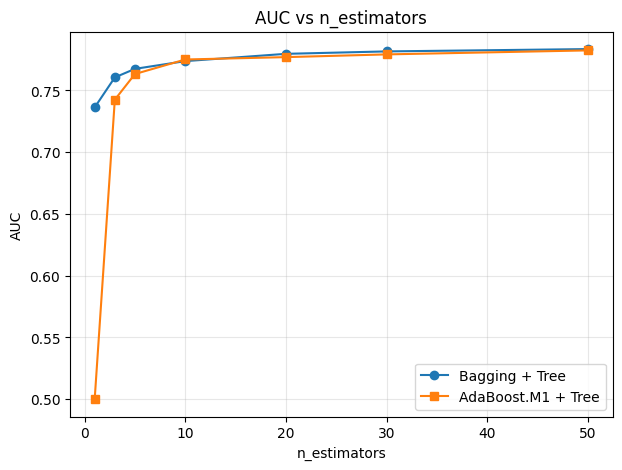

In [49]:
n_list = [1, 3, 5, 10, 20, 30, 50]

bag_curve = []
for n in n_list:
    m = MyBagging(make_tree(max_depth=12), n_estimators=n, sample_ratio=1.0, random_state=0)
    m.fit(X_train, y_train)
    a = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    bag_curve.append(a)
    print(f'  Bagging+Tree n={n:3d}  AUC={a:.4f}')

ada_curve = []
for n in n_list:
    m = MyAdaBoostM1(make_tree(max_depth=3), n_estimators=n, random_state=0)
    m.fit(X_train, y_train)
    a = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    ada_curve.append(a)
    print(f'  AdaBoost+Tree n={n:3d}  AUC={a:.4f}')

plt.figure(figsize=(7,5))
plt.plot(n_list, bag_curve, '-o', label='Bagging + Tree')
plt.plot(n_list, ada_curve, '-s', label='AdaBoost.M1 + Tree')
plt.xlabel('n_estimators')
plt.ylabel('AUC')
plt.title('AUC vs n_estimators')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

再看一下 AdaBoost 中基分类器深度的影响（弱分类器假设是不是真的成立）：

  [AdaBoost.M1] 第 1/30 轮: err=0.2262, alpha=0.6150
  [AdaBoost.M1] 第 2/30 轮: err=0.3056, alpha=0.4104
  [AdaBoost.M1] 第 3/30 轮: err=0.3818, alpha=0.2409
  [AdaBoost.M1] 第 4/30 轮: err=0.4519, alpha=0.0965
  [AdaBoost.M1] 第 5/30 轮: err=0.4378, alpha=0.1251
  [AdaBoost.M1] 第 6/30 轮: err=0.4553, alpha=0.0895
  [AdaBoost.M1] 第 7/30 轮: err=0.4545, alpha=0.0913
  [AdaBoost.M1] 第 8/30 轮: err=0.4488, alpha=0.1029
  [AdaBoost.M1] 第 9/30 轮: err=0.4535, alpha=0.0932
  [AdaBoost.M1] 第 10/30 轮: err=0.4540, alpha=0.0922
  [AdaBoost.M1] 第 11/30 轮: err=0.4686, alpha=0.0630
  [AdaBoost.M1] 第 12/30 轮: err=0.4679, alpha=0.0644
  [AdaBoost.M1] 第 13/30 轮: err=0.4672, alpha=0.0656
  [AdaBoost.M1] 第 14/30 轮: err=0.4629, alpha=0.0744
  [AdaBoost.M1] 第 15/30 轮: err=0.4808, alpha=0.0384
  [AdaBoost.M1] 第 16/30 轮: err=0.4722, alpha=0.0556
  [AdaBoost.M1] 第 17/30 轮: err=0.4813, alpha=0.0374
  [AdaBoost.M1] 第 18/30 轮: err=0.4922, alpha=0.0156
  [AdaBoost.M1] 第 19/30 轮: err=0.4925, alpha=0.0151
  [AdaBoost.M1] 第 20/

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22120 (\N{CJK UNIFIED IDEOGRAPH-5668}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Framewo

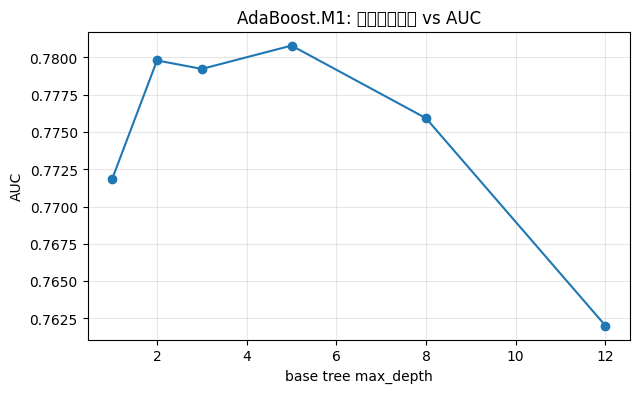

In [50]:
depth_list = [1, 2, 3, 5, 8, 12]
depth_aucs = []
for d in depth_list:
    m = MyAdaBoostM1(make_tree(max_depth=d), n_estimators=30, random_state=0)
    m.fit(X_train, y_train)
    a = roc_auc_score(y_test, m.predict_proba(X_test)[:, 1])
    depth_aucs.append(a)
    print(f'  AdaBoost+Tree(max_depth={d})  AUC={a:.4f}')

plt.figure(figsize=(7,4))
plt.plot(depth_list, depth_aucs, '-o')
plt.xlabel('base tree max_depth')
plt.ylabel('AUC')
plt.title('AdaBoost.M1: 基分类器深度 vs AUC')
plt.grid(alpha=0.3)
plt.show()

从两张曲线看：
* **Bagging 的 AUC 随 n_estimators 单调递增**：1 棵 0.7363 → 50 棵 0.7835，但 20 棵以后基本就是“加一棵涨一点点”的状态了。这和 Bagging 主要降方差的原理一致——基模型越多方差越小，但偏差降不下去，所以收益递减。
* **AdaBoost 也是越多越好，但起步比 Bagging 慢得多**：1 棵的时候 AUC 只有 0.50（基本等于瞎猜），3 棵以后才追上来。这符合 AdaBoost 的逻辑：单棵弱分类器本来就不强，要靠后面的轮次去“补”前面分错的样本。
* **基分类器深度的影响**：max_depth = 2 时最高（0.7798），到 max_depth = 12 反而掉到 0.7620。说明 AdaBoost 还是更喜欢“弱分类器”——基模型太强一上来就把训练集学得太死，后面 alpha 算出来很大，错的样本权重涨得也快，反而容易过拟合。